# `530_sports_pipeline.ipynb` — pipeline conductor

**Gameplan:** `current_documents/sports_documents/SPORTS_DATA_GAMEPLAN.md`

**Run order:** **CELL 1** (imports) → **CELL 2** (all booleans & paths) → **CELL 4** (`conductor.run_conductor`, or set **`RUN_ALL_PERF_METRICS`** in CELL 4 to sweep every `perf_metric` key after a single panel build). No piecemeal stage cells required.

Implementation lives in **`sports_pipeline/`** (see **`conductor.py`**). Legacy notebooks under **`obsolete_files/sports_gameplan_old/`** are reference only.

**Working directory:** project root (folder containing `datasets/` and `sports_pipeline/`).

**Optional:** `pip install -e .` so `import sports_pipeline` works without the `sys.path` cell.

In [1]:
# CELL 1 — make package importable (skip if you ran: pip install -e .)
# Full SR scrape (optional): pip install -e '.[scrape]'
# If you edited sports_pipeline/*.py: Kernel → Restart, then re-run cells (Python keeps old imports otherwise).
%matplotlib inline
import sys
from pathlib import Path

PROJECT_ROOT = Path(".").resolve()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from sports_pipeline import (
    bpm_merge,
    conductor,
    data_integrity,
    dataset_coverage,
    draft_match,
    ingest_box,
    panel_build,
    panel_rebuild,
    paths,
    perf_metric,
    scrape_bpm,
    sr_bpm,
)
from sports_pipeline.config import PipelineConfig

print("PROJECT_ROOT:", PROJECT_ROOT)
print("panel CSV:", paths.panel_530_csv())

PROJECT_ROOT: /Users/charleslevine/Library/CloudStorage/Dropbox/1-Documents/00- Dissertation/0-Next_Chapter/Code_and_Data/New SQL and PY Code/Cursor Workspace PDE
panel CSV: /Users/charleslevine/Library/CloudStorage/Dropbox/1-Documents/00- Dissertation/0-Next_Chapter/Code_and_Data/New SQL and PY Code/Cursor Workspace PDE/datasets/mbb/player_season_panel_530.csv


In [2]:
# CELL 2 — all pipeline toggles (edit here only; then run CELL 4)
#
# === Performance & panel source =================================================
# perf_metric: list of user keys (see markdown + perf_metric.perf_options_df()).
#   box: "minutes", "ppm"  |  SR: "bpm", "obpm"/"opm", "dbpm"/"dpm", "per", "ws40", "ws", "tspct"/"ts_pct"
#   One-shot run (CELL 4): conductor uses the first list entry. Two+ entries (without RUN_ALL):
#   CELL 4 prepares the panel once then loops each key (same as RUN_ALL sweep).
#   If CELL 4 RUN_ALL_PERF_METRICS=True: CFG.perf_metric[0] picks PANEL for the final .shape line when
#   that key ran; if it was skipped, PANEL is the last metric in the sweep.
# use_prebuilt_panel_csv: True = load player_season_panel_530.csv; False = rebuild from ESPN box + draft lookup
# panel_season_min / max: None = every season in the box file
# ventiles: number of bins on poolq_loo for the draft-rate EDA (20 quantile bins = "ventiles")
# poolq_binning: "quantile" (pd.qcut, ~equal n/bin, same as 520 "quantile") or "equal_width" (pd.cut)
# poolq_winsor_quantiles: e.g. (0.01, 0.99) or None
# perf_zscore_within_season: True = z-score perf within each collegiate season before LOO (see markdown cell)
# restrict_teams_by_draftees: True = ventiles/LPM/integrity use only teams with ≥1 drafted player (see draftee_restriction)
# draftee_restriction: "all_time" = team_id ever has Y_draft=1 in sample; "season" = that (team_id, season) roster has ≥1
# print_unmatched_school_lists: True = after prepare_panel, print draft-unmapped colleges + SR-unmatched ESPN teams
# unmatched_school_report_max_lines: None = print all; int = cap lines per section (full data stays in the CSVs)
# ventile_plot_show_metadata: False = ventile PNG is chart only (less bottom margin); provenance still in .txt + console
# ventile_eda_plot_style: "poolq_line" (default) = one panel vs mean poolq; "bins_bars_520" = bar chart vs bin index only (Cell 11–style bars), metadata below if ventile_plot_show_metadata
#
# === SR refresh (before analysis) ===============================================
# run_sr_refresh: True = crosswalk → jobs → optional scrape → match, then refresh panel SR columns
# sr_refresh_do_scrape: True hits the network (needs pip install -e '.[scrape]')
#
# === Conductor steps (run_conductor) ============================================
# run_stage3_status: print ingest/draft/SR stub dicts
# run_data_integrity_report / run_yearly_coverage_chart / run_ventile_eda / run_dirty_lpm
# export_panel_after_run: True = write final PANEL to CSV (canonical path unless export_panel_dest set)
#
# === Coverage / integrity windows ===============================================
# analysis_season_min/max: shade coverage chart + fix integrity text when both set
#
CFG = PipelineConfig(
    perf_metric=["minutes", "ppm"],
    use_prebuilt_panel_csv=False,
    panel_season_min=2011,
    panel_season_max=2021,
    min_minutes=0.0,
    ventiles=25,
    poolq_binning="quantile",
    poolq_winsor_quantiles=(.05,.95),
    perf_zscore_within_season=True,
    restrict_teams_by_draftees=False,
    draftee_restriction="season",
    print_unmatched_school_lists=False,
    unmatched_school_report_max_lines=None,
    run_sr_refresh=True,
    sr_refresh_do_crosswalk=True,
    sr_refresh_do_scrape_jobs=True,
    sr_refresh_do_scrape=False,
    sr_refresh_do_match=True,
    run_stage3_status=False,
    run_data_integrity_report=False,
    run_yearly_coverage_chart=False,
    run_ventile_eda=True,
    run_dirty_lpm=True,
    export_panel_after_run=False,
    export_panel_dest=None,
    show_quadratic_lpm_on_eda_plot=True,
    ventile_plot_show_metadata=True,
    ventile_eda_plot_style="poolq_line",
    analysis_season_min=2011,
    analysis_season_max=2021,
    draft_year_before_season=1,
    draft_year_after_season=5,
    run_spine_refresh=False,
    run_draft_match=False,
    run_sr_scrape=False,
    sr_scrape_contact=None,
    sr_scrape_max_fetches=None,
)
CFG.exports_dir = PROJECT_ROOT / "datasets" / "mbb" / "exports_inverted_u_v0"
CFG

PipelineConfig(use_prebuilt_panel_csv=False, panel_season_min=2011, panel_season_max=2021, min_minutes=0.0, ventiles=25, poolq_binning='quantile', exports_dir=PosixPath('/Users/charleslevine/Library/CloudStorage/Dropbox/1-Documents/00- Dissertation/0-Next_Chapter/Code_and_Data/New SQL and PY Code/Cursor Workspace PDE/datasets/mbb/exports_inverted_u_v0'), perf_metric=['minutes', 'ppm'], show_quadratic_lpm_on_eda_plot=True, ventile_plot_show_metadata=True, ventile_eda_plot_style='poolq_line', poolq_winsor_quantiles=(0.05, 0.95), perf_zscore_within_season=True, print_unmatched_school_lists=False, unmatched_school_report_max_lines=None, restrict_teams_by_draftees=False, draftee_restriction='season', run_sr_refresh=True, sr_refresh_do_crosswalk=True, sr_refresh_do_scrape_jobs=True, sr_refresh_do_scrape=False, sr_refresh_do_match=True, run_stage3_status=False, run_data_integrity_report=False, run_yearly_coverage_chart=False, run_ventile_eda=True, run_dirty_lpm=True, export_panel_after_run=Fa

### Performance metrics (`perf_metric`) and z-scores

**CELL 2** sets **`perf_metric`** to a **list** of keys (e.g. `["obpm"]` or `["obpm", "ws40"]`). A one-shot `run_conductor` uses the **first** entry; listing several keys triggers a sweep in **CELL 4** (prepare once, then one analysis pass per key). Duplicates are dropped at init (case-insensitive).

**ESPN box (no SR merge)**

- **`minutes`** — Player–season–team total minutes from game-level box. Leave-one-out (LOO) pool quality = mean teammate **minutes** excluding self.
- **`ppm`** — Points per minute from box. LOO = mean teammate **PPM** excluding self.

**Sports Reference** (needs `DO_NOT_ERASE/bpm_player_season_matched.csv` on the panel)

- **`bpm`** — Box Plus/Minus; SR all-in-one advanced impact statistic.
- **`obpm`** / **`opm`** — Offensive BPM (same matched row as BPM).
- **`dbpm`** / **`dpm`** — Defensive BPM.
- **`per`** — Player efficiency rating; composite efficiency index.
- **`ws40`** — Win shares **per 40 minutes** (rate).
- **`ws`** — Win **shares** (season total at the matched row).
- **`tspct`** or **`ts_pct`** — True shooting **percentage** from SR (panel column `ts_pct_sr`).

**`perf_zscore_within_season`** — If `True`, `perf` is replaced by its **z-score within each collegiate season** before LOO. Then `poolq_loo` is in **within-season SD units** (useful for comparing metrics or multi-metric plots later).

### Bins on `poolq_loo` (`ventiles` + `poolq_binning`)

- **`ventiles`** — Number of bins (default 20). The plot title says **ventiles** only when `ventiles=20` **and** `poolq_binning="quantile"`: that is the usual “20 quantile groups,” i.e. ~5% of the sample per bin.
- **`poolq_binning="quantile"`** — `pd.qcut` on `poolq_loo` (~equal **counts** per bin). Matches a 520-style **quantile** binning choice.
- **`poolq_binning="equal_width"`** — `pd.cut` on the min–max range of `poolq_loo` (equal **width** on the x-axis). Matches 520 **equal_width**. Export filenames add `_poolqeqwidth` so you do not overwrite quantile runs.
- **`ventile_eda_plot_style`** — `"poolq_line"` (default): one panel, draft rate vs **mean** `poolq_loo` per bin (Y from 0). `"bins_bars_520"`: **bars only** vs ventile index (1 = lowest poolq), **steelblue** / white edges (Cell 11 left panel); same metadata block below as `poolq_line` when `ventile_plot_show_metadata=True`. Y-axis from 0. Export slug adds `_ventilebars520`.

**Export filenames** — Slugs use the **active** perf key (first in the list for that run), plus optional `_zwithinseason`, `_poolqeqwidth`, `_ventilebars520`, and draftee-restriction tokens.

### Unmatched schools (CELL 2 toggles)

- **Draft** — `print_unmatched_school_lists=True` prints colleges from the NBA draft register that never mapped to your ESPN school linkage. Source QA file: `datasets/mbb/draft_unmapped_colleges.csv` (from your draft-match export).
- **Sports Reference** — Same toggle prints ESPN **teams** (with `team_id`, display name, `school_slug`) that still have player-season rows without a BPM merge hit after the last `run_match`. Source: `datasets/mbb/bpm_panel_rows_unmatched.csv`. Small religious colleges, HBCUs, NAIA, etc. often show up here when SR slugs or rosters do not line up—useful for planning manual aliases, conference-level imputation, or alternate pool-quality proxies.

### One-shot pipeline

Set **every** toggle in **CELL 2**, then run **CELL 4** (`conductor.run_conductor` when `perf_metric` has one key, or an automatic sweep when you list several). No other cells are required for the main path.

- **Box-only perf:** `use_prebuilt_panel_csv=False`, `run_sr_refresh=False`, set `perf_metric` to `["minutes"]` or `["ppm"]`.
- **SR perf:** ensure `bpm_player_season_matched.csv` is current (set `run_sr_refresh=True` and flip the `sr_refresh_*` flags when you want scrape/match), then `perf_metric` = `["bpm"]` / `["opm"]` / `["dpm"]` (or equivalent aliases).

### Performance metric

Set **`perf_metric`** in **CELL 2** as a **list** of keys (e.g. `["obpm"]`). Run **`perf_metric.perf_options_df()`** for keys and plot labels.

### Optional: Stage 3 status lines

If **`CFG.run_stage3_status`** is True, CELL 4 prints **`ingest_box` / `draft_match` / `sr_bpm`** return dicts. Day-to-day SR work is **`CFG.run_sr_refresh`** (not `run_sr_scrape` alone).

Crosswalk: 1343 rows → /Users/charleslevine/Library/CloudStorage/Dropbox/1-Documents/00- Dissertation/0-Next_Chapter/Code_and_Data/New SQL and PY Code/Cursor Workspace PDE/datasets/mbb/DO_NOT_ERASE/sr_school_slug_crosswalk.csv
Scrape jobs: 6533 slug×season → /Users/charleslevine/Library/CloudStorage/Dropbox/1-Documents/00- Dissertation/0-Next_Chapter/Code_and_Data/New SQL and PY Code/Cursor Workspace PDE/datasets/mbb/bpm_scrape_jobs.csv
Rows with BPM matched: 50,973 / 104,790 (48.6%)
Wrote /Users/charleslevine/Library/CloudStorage/Dropbox/1-Documents/00- Dissertation/0-Next_Chapter/Code_and_Data/New SQL and PY Code/Cursor Workspace PDE/datasets/mbb/DO_NOT_ERASE/bpm_player_season_matched.csv rows: 50,973
Wrote /Users/charleslevine/Library/CloudStorage/Dropbox/1-Documents/00- Dissertation/0-Next_Chapter/Code_and_Data/New SQL and PY Code/Cursor Workspace PDE/datasets/mbb/bpm_panel_rows_unmatched.csv rows: 53,817 (QA)
SR refresh — crosswalk_teams=1343 | scrape_jobs=6533 | matched_rows=5097

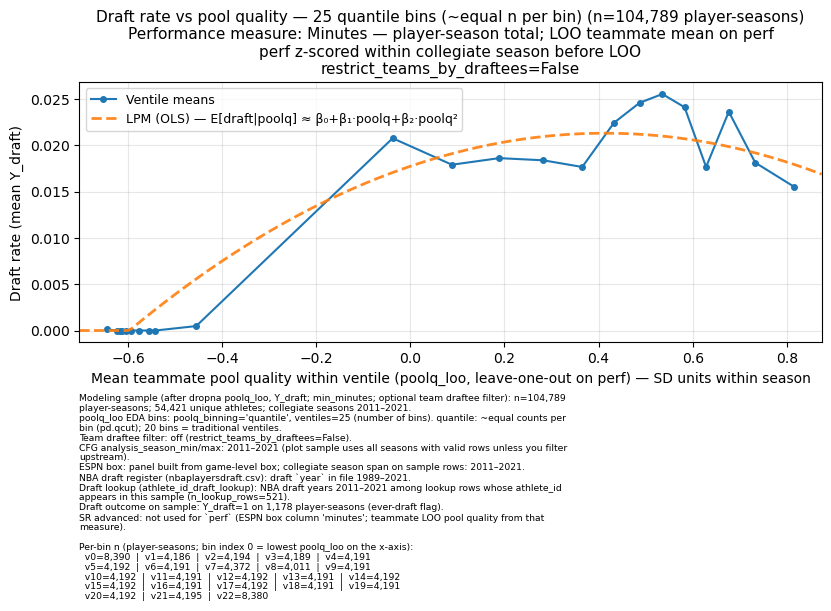

--- LPM (statsmodels) ---
                            OLS Regression Results                            
Dep. Variable:                Y_draft   R-squared:                       0.009
Model:                            OLS   Adj. R-squared:                  0.009
Method:                 Least Squares   F-statistic:                     464.0
Date:                Thu, 02 Apr 2026   Prob (F-statistic):          2.33e-201
Time:                        12:38:31   Log-Likelihood:                 87519.
No. Observations:              104789   AIC:                        -1.750e+05
Df Residuals:                  104786   BIC:                        -1.750e+05
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0177     

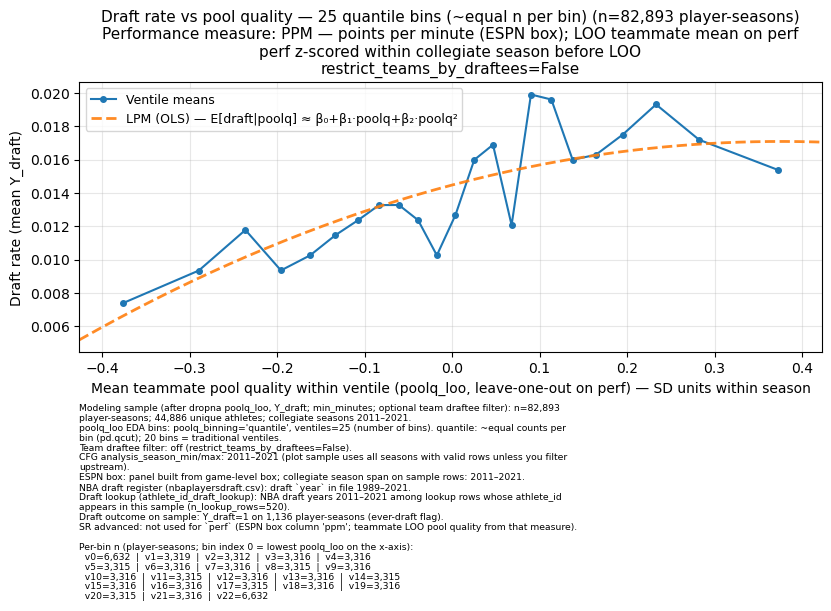

--- LPM (statsmodels) ---
                            OLS Regression Results                            
Dep. Variable:                Y_draft   R-squared:                       0.001
Model:                            OLS   Adj. R-squared:                  0.001
Method:                 Least Squares   F-statistic:                     28.02
Date:                Thu, 02 Apr 2026   Prob (F-statistic):           6.82e-13
Time:                        12:38:31   Log-Likelihood:                 60787.
No. Observations:               82893   AIC:                        -1.216e+05
Df Residuals:                   82890   BIC:                        -1.215e+05
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0145     

(104790, 24)

In [3]:
# CELL 4 — run full 530 pipeline (panel → perf/LOO → integrity → coverage → ventiles → LPM)
#
# RUN_ALL_PERF_METRICS: True = build/refresh the panel once, then run analysis for every
#   user key in perf_metric.perf_options_df()["metric"] (each export slug differs).
#   Metrics whose source column is missing on the panel are skipped with a message.
# False = use CFG.perf_metric: one conductor pass if it has a single key; if you list 2+ keys,
#   CELL 4 prepares once then loops (same pattern as RUN_ALL).
# If export_panel_after_run=True while sweeping, each iteration overwrites the same panel CSV path —
#   leave it False for multi-metric runs unless you set export_panel_dest per metric yourself.
#
# Coverage charts (BOX / draft / SR by year) do NOT depend on perf_metric — only filenames used
# export_plot_slug. When sweeping multiple metrics and run_yearly_coverage_chart=True, coverage
# runs once after prepare_panel; the sweep turns coverage off so you do not get duplicate PNGs/CSVs.
#
from dataclasses import replace

RUN_ALL_PERF_METRICS = False

metrics = (
    perf_metric.perf_options_df()["metric"].tolist()
    if RUN_ALL_PERF_METRICS
    else list(CFG.perf_metric)
)
sweep = RUN_ALL_PERF_METRICS or len(metrics) != 1

if sweep:
    if CFG.run_stage3_status:
        print("--- Stage 3 status (stubs / optional scrape) ---")
        print(ingest_box.run(CFG))
        print(draft_match.run(CFG))
        print(sr_bpm.run(CFG))
        print()
    panel_base = conductor.prepare_panel(CFG)
    if CFG.run_yearly_coverage_chart:
        print("--- Yearly coverage exports (once; same for every perf_metric in the sweep) ---")
        dataset_coverage.export_yearly_coverage_chart(CFG, show=True)
    OUT_BY_METRIC = {}
    skipped = []
    for m in metrics:
        if not conductor.panel_has_metric_column(panel_base, m):
            skipped.append(m)
            continue
        print(f"\n========== perf_metric={m!r} ==========\n")
        cfg_m = replace(CFG, perf_metric=[m], run_yearly_coverage_chart=False)
        OUT_BY_METRIC[m] = conductor.run_conductor_from_panel(cfg_m, panel_base.copy(deep=True))
    if skipped:
        print(f"--- Skipped (missing panel column): {skipped} ---")
    OUT = OUT_BY_METRIC
    if OUT_BY_METRIC:
        primary = CFG.perf_metric[0]
        PANEL = (
            OUT_BY_METRIC[primary]["PANEL"]
            if primary in OUT_BY_METRIC
            else list(OUT_BY_METRIC.values())[-1]["PANEL"]
        )
    else:
        PANEL = None
else:
    OUT = conductor.run_conductor(CFG)
    PANEL = OUT["PANEL"]

PANEL.shape if PANEL is not None else None

## Export

- **`CFG.export_panel_after_run = True`** in **CELL 2** saves the final **`PANEL`** after analysis (default file: `player_season_panel_530.csv`; override with **`CFG.export_panel_dest`**).
- SR refresh is controlled only by **`CFG.run_sr_refresh`** and **`sr_refresh_do_*`** in CELL 2.